<a href="https://colab.research.google.com/github/2d-game-dev/ComputerVisionProject/blob/main/NEWERVersionOFCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ce2bdqFeT7e9MGJbnEPa")
project = rf.workspace("my-workspace-y2ace").project("cctv-naxyo-drk6y")
dataset = project.version(1).download("yolov5")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cctv-1 in yolov5pytorch:: 100%|██████████| 7479/7479 [00:03<00:00, 2172.53it/s]


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

In [36]:
class GridDataset(Dataset):
    def __init__(self, images_path, labels_path, grid_size=7, max_images=1000):
        self.images = []
        self.labels = []
        self.grid_size = grid_size

        img_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]

        for img_file in img_files[:max_images]:
            label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
            label_path = os.path.join(labels_path, label_file)

            grid = np.zeros((grid_size, grid_size, 5))  # [conf, x, y, w, h]

            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) == 5:
                            _, x, y, w, h = map(float, parts)

                            gx = int(x * grid_size)
                            gy = int(y * grid_size)

                            if gx < grid_size and gy < grid_size:
                                grid[gy, gx] = [1, x, y, w, h]

            self.images.append(os.path.join(images_path, img_file))
            self.labels.append(grid)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        img = img.resize((224, 224))
        img = np.array(img) / 255.0
        img = torch.FloatTensor(img).permute(2, 0, 1)

        label = torch.FloatTensor(self.labels[idx])
        return img, label

In [37]:
class GridDetectionModel(nn.Module):
    def __init__(self, grid_size=7):
        super().__init__()
        self.grid_size = grid_size

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Linear(128 * 14 * 14, 1024)
        self.output = nn.Linear(1024, grid_size * grid_size * 5)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc(x))
        x = self.output(x)
        x = x.view(-1, self.grid_size, self.grid_size, 5)

         # ✅ Apply activations
        x[..., 0] = torch.sigmoid(x[..., 0])   # confidence (0–1)
        x[..., 1:] = torch.sigmoid(x[..., 1:]) # bbox normalized (0–1)

        return x

In [38]:
def detection_loss(pred, target):
    obj_mask = target[..., 0] > 0

    loss_conf = ((pred[..., 0] - target[..., 0]) ** 2).mean()

    if obj_mask.sum() > 0:
        loss_bbox = ((pred[obj_mask][..., 1:] - target[obj_mask][..., 1:]) ** 2).mean()
    else:
        loss_bbox = 0

    return loss_conf + loss_bbox

In [39]:
dataset_path = "/content/cctv-1"

train_dataset = GridDataset(f"{dataset_path}/train/images", f"{dataset_path}/train/labels")
val_dataset = GridDataset(f"{dataset_path}/valid/images", f"{dataset_path}/valid/labels")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GridDetectionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.003)

epochs = 15
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, targets in tqdm(train_loader):
        images, targets = images.to(device), targets.to(device)

        preds = model(images)
        loss = detection_loss(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ✅ IMPORTANT FIX: average loss
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

100%|██████████| 63/63 [01:35<00:00,  1.52s/it]


Epoch 1: Loss = 0.0781


100%|██████████| 63/63 [01:34<00:00,  1.51s/it]


Epoch 2: Loss = 0.0688


100%|██████████| 63/63 [01:34<00:00,  1.50s/it]


...

Epoch 13: Loss = 0.0365


100%|██████████| 63/63 [01:45<00:00,  1.67s/it]


Epoch 14: Loss = 0.0333


100%|██████████| 63/63 [01:46<00:00,  1.69s/it]

Epoch 15: Loss = 0.0307


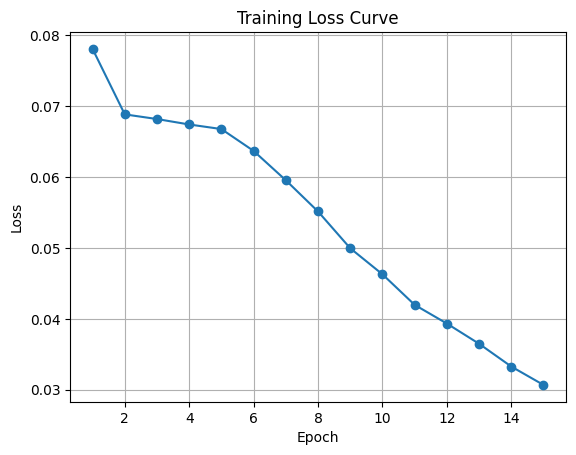

In [41]:
plt.figure()
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()

In [42]:
def detect_intrusion(model, image_path, restricted_zone=[0.3,0.4,0.7,0.6], threshold=0.1):
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224,224))
    img_tensor = torch.FloatTensor(np.array(img_resized)/255.0).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)[0].cpu().numpy()

    print("Max confidence:", pred[...,0].max())

    intrusion = False
    boxes = []

    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            conf = pred[i,j,0]
            if conf > threshold:
                x,y,w,h = pred[i,j,1:]
                boxes.append((x,y,w,h))

                if restricted_zone[0] < x < restricted_zone[2] and restricted_zone[1] < y < restricted_zone[3]:
                    intrusion = True

    # Visualization
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    h_img, w_img = img.size[1], img.size[0]

    # Draw restricted zone
    rz = patches.Rectangle((restricted_zone[0]*w_img, restricted_zone[1]*h_img),
                           (restricted_zone[2]-restricted_zone[0])*w_img,
                           (restricted_zone[3]-restricted_zone[1])*h_img,
                           edgecolor='red', facecolor='red', alpha=0.3)
    ax.add_patch(rz)

    # Draw boxes
    for (x,y,w,h) in boxes:
        rect = patches.Rectangle(((x-w/2)*w_img,(y-h/2)*h_img),
                                 w*w_img,h*h_img,
                                 edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)

    if intrusion:
        plt.title("🚨 INTRUSION DETECTED", color="red")
    else:
        plt.title("✅ SAFE")

    plt.axis('off')
    plt.show()

    return intrusion


Max confidence: 0.49597478


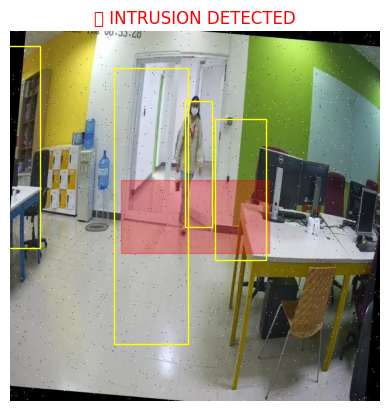

True

In [43]:
test_image = val_dataset.images[0]
detect_intrusion(model, test_image)

Frame 1
Max confidence: 0.49597478


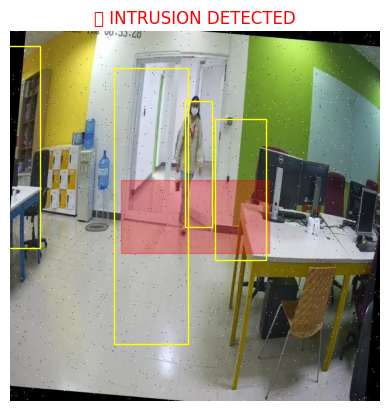

Frame 2
Max confidence: 0.50653887


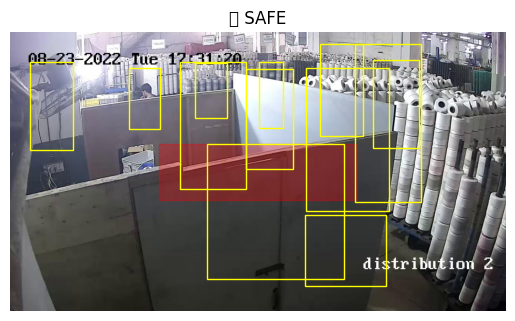

Frame 3
Max confidence: 0.50276715


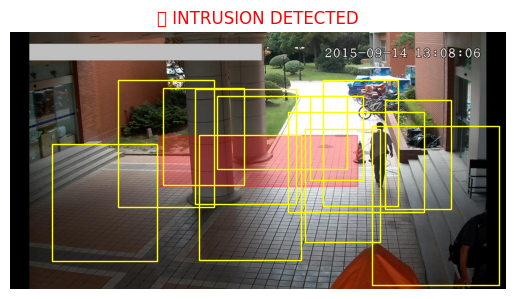

Frame 4
Max confidence: 0.16339989


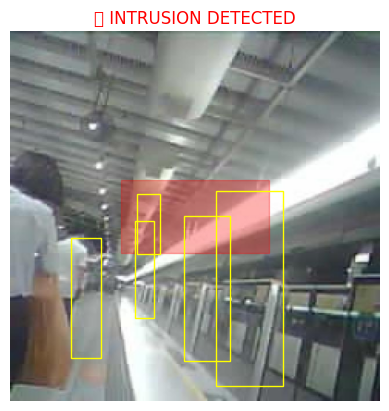

Frame 5
Max confidence: 0.14383826


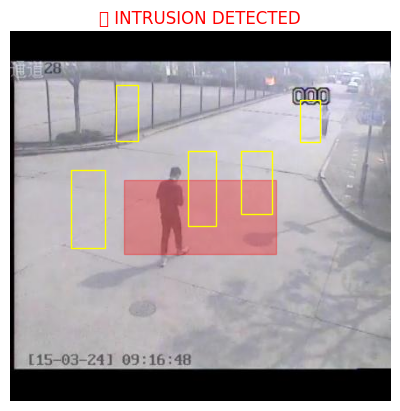

Frame 6
Max confidence: 0.3333208


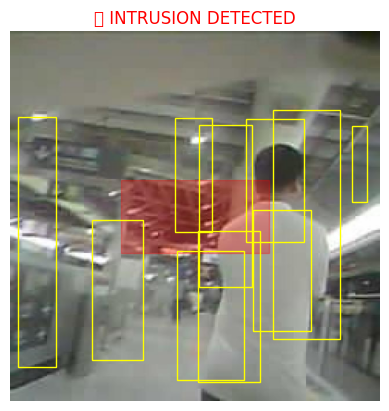

Frame 7
Max confidence: 0.25428268


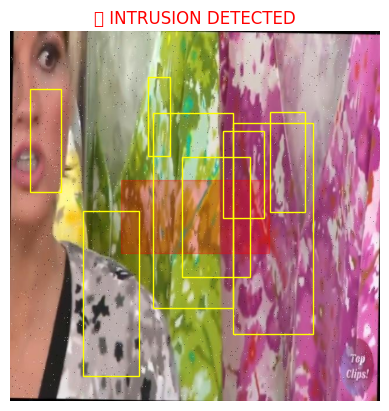

Frame 8
Max confidence: 0.475764


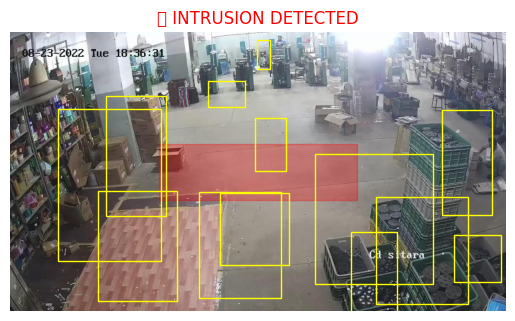

Frame 9
Max confidence: 0.5172857


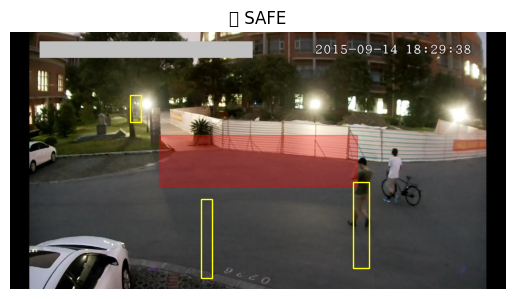

Frame 10
Max confidence: 0.52281743


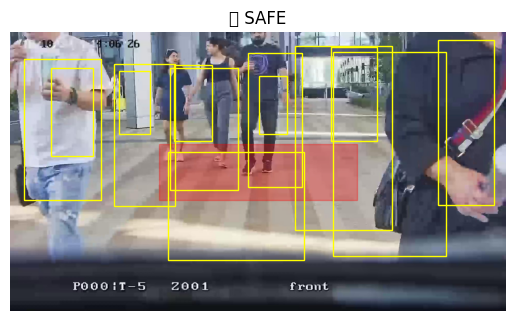

In [44]:
def simulate_cctv(model, folder, delay=1):
    images = os.listdir(folder)

    for i, img in enumerate(images[:10]):
        print(f"Frame {i+1}")
        detect_intrusion(model, os.path.join(folder, img))
        plt.pause(delay)

simulate_cctv(model, os.path.dirname(val_dataset.images[0]))